KNN Regression

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## DataCleansing

In [37]:
input_df=pd.read_csv('job_placement.csv')


In [46]:
from sklearn.preprocessing import LabelEncoder

# One-hot encode the stream column and convert to 0/1
boolean_encoded = pd.get_dummies(
    input_df["stream"], 
    prefix="boolean",
    dtype=int
)

# Convert placement_status to 0/1
le = LabelEncoder()
input_df["placement_status"] = le.fit_transform(input_df["placement_status"])

# Combine with original dataframe
input_df_encoded = pd.concat([input_df, boolean_encoded], axis=1)

# Select required columns
new_df = input_df_encoded[
    [
        "age",
        "placement_status",
        "gpa",
        "boolean_Computer Science",
        "boolean_Information Technology",
        "boolean_Electrical Engineering",
        "boolean_Mechanical Engineering",
        "boolean_Electronics and Communication"
    ]
]

new_df.head()

,age,placement_status,gpa,boolean_Computer Science,boolean_Information Technology,boolean_Electrical Engineering,boolean_Mechanical Engineering,boolean_Electronics and Communication
0,25,1,3.7,1,0,0,0,0
1,24,1,3.6,0,0,1,0,0
2,26,1,3.8,0,0,0,1,0
3,23,0,3.5,0,1,0,0,0
4,24,1,3.9,1,0,0,0,0


In [47]:
new_df.to_csv("preprocessed_data.csv", index=False)

In [48]:
df = new_df

## KNN Model

### train & inference

In [49]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:


# Select features and target
features = [
    "age",
    "gpa",
    "boolean_Computer Science",
    "boolean_Information Technology",
    "boolean_Electrical Engineering",
    "boolean_Mechanical Engineering",
    "boolean_Electronics and Communication"
]

X = new_df[features]
y = new_df["placement_status"]





# Scale features (important for KNN)
# because higher age doesn't mean higher distance neccessarily. 
# this is just to make sure both age and gpa is on same range of 0 to 1. 
scaler = MinMaxScaler()
X = scaler.fit_transform(X)




# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)


# Create KNN model
knn = KNeighborsClassifier(n_neighbors=5)


# Train the model
knn.fit(X_train, y_train)


# Make predictions
y_pred = knn.predict(X_test)




### Evaluate

In [56]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

Accuracy: 74.86 %
Error Rate: 25.14 %

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.11      0.19        46
           1       0.75      0.98      0.85       129

    accuracy                           0.75       175
   macro avg       0.69      0.54      0.52       175
weighted avg       0.72      0.75      0.68       175



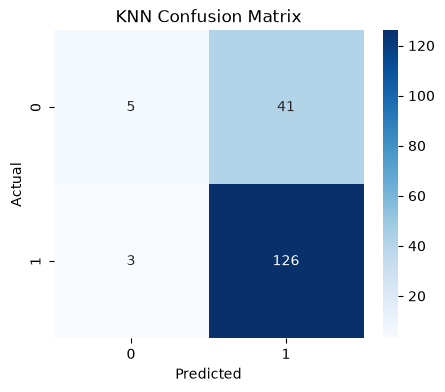

ROC-AUC Score: 0.706


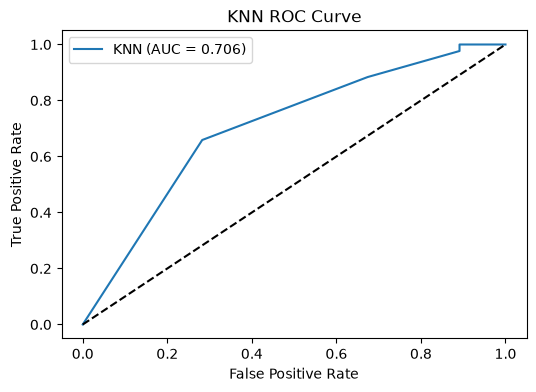

In [58]:
# Import additional evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)


# ============================
# Model Evaluation
# ============================

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")


# Error Rate
error_rate = 1 - accuracy

print("Error Rate:", round(error_rate * 100, 2), "%")


# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ROC-AUC
# Need probability predictions instead of class predictions
y_prob = knn.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc, 3))


# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))

plt.plot(
    fpr,
    tpr,
    label=f"KNN (AUC = {roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.show()